In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer
from sklearn.mixture import GaussianMixture
from statsmodels.formula.api import ols
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [91]:
from data import health_df, weather_df, df_wide, extreme_df, smooth_income_strict, H_KEYS, C_KEYS, urban_df, ECON_KEYS
extreme_df = pd.read_csv('../results/trends/extremes/extreme_df.csv')

In [6]:
merged_df = pd.merge(health_df, urban_df[['country', 'year', 'city', 'rural']], on=['country', 'year'], how='left')
right_df = merged_df[['country', 'year', 'gdp', 'health_exp', 'city', 'rural']].drop_duplicates()
right_df['health_exp'] = right_df['health_exp'].interpolate(method='linear', limit_direction='both')
df_wide1 = df_wide.merge(right_df, on=['country', 'year'], how='left')
df_wide1

,country,year,annual_cold_intensity_sum,annual_dry_area,annual_freeze_burden,annual_heat_intensity_sum,annual_potential_evap,annual_total_evap,anomaly_cold_days,anomaly_heat_days,...,winter_mean_snow_density,income_level_mode,income_level,DALYs_Cardiovascular_diseases,DALYs_Chronic_respiratory_diseases,DALYs_Environmental_heat_and_cold_exposure,gdp,health_exp,city,rural
0,Algeria,1990,11.531196,348.501833,3.016917,6.013540,-0.092349,-0.002941,12.0,13.0,...,103.169410,LM,LM,11253.922792,1002.651708,10.462595,2445.183327,3.214854,27.6,33.0
1,Algeria,1991,25.840975,349.056344,7.566541,6.577771,-0.091692,-0.002962,20.0,11.0,...,104.580630,LM,LM,11022.731268,986.116056,10.067621,1759.112016,3.214854,28.1,32.3
2,Algeria,1992,23.866690,352.153994,6.623073,1.931110,-0.091099,-0.002596,19.0,4.0,...,103.108215,LM,LM,10816.110335,973.097973,9.733580,1802.693008,3.214854,28.7,31.6
3,Algeria,1993,52.616404,353.177538,7.721194,10.181198,-0.093595,-0.002307,32.0,20.0,...,103.569466,LM,LM,10633.970031,961.796857,9.429356,1831.048010,3.214854,29.2,31.0
4,Algeria,1994,18.151319,349.665555,5.354840,1.515310,-0.093407,-0.002875,21.0,7.0,...,104.111690,LM,LM,10447.598031,946.767738,9.170467,1525.540618,3.214854,29.6,30.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1355,Zimbabwe,2019,13.447975,296.068667,0.000000,63.232002,-0.114768,-0.021142,15.0,38.0,...,99.999980,L,LM,5166.560199,1306.706575,29.446950,2184.329239,3.232682,22.3,65.9
1356,Zimbabwe,2020,18.204528,274.318280,0.000000,30.671897,-0.104341,-0.020214,28.0,18.0,...,99.999980,L,LM,5063.431220,1197.018880,28.413170,2059.674454,2.954401,21.8,66.4
1357,Zimbabwe,2021,20.951201,272.543149,0.000000,34.560280,-0.101629,-0.024244,23.0,32.0,...,99.999980,L,LM,5785.320753,1155.121787,27.307866,2613.605421,2.671119,22.0,66.2
1358,Zimbabwe,2022,6.950287,268.443551,0.000000,8.762840,-0.081898,-0.021897,14.0,10.0,...,99.999980,L,LM,4924.575083,1230.229784,28.093528,2536.400502,3.395195,22.2,65.9


Countries: 40
Climate features: 43
Index unique: True

PCA: 7 components explain 85% variance

OPTIMAL K SELECTION — ALL VARIANTS
------------------------------------------------------------

  A: All climate + DALYs:
    k=2: silhouette=0.353 ←
    k=3: silhouette=0.322
    k=4: silhouette=0.279
    k=5: silhouette=0.195
    k=6: silhouette=0.181
    k=7: silhouette=0.197
    k=8: silhouette=0.173

  B: Health-relevant + DALYs:
    k=2: silhouette=0.479
    k=3: silhouette=0.490 ←
    k=4: silhouette=0.261
    k=5: silhouette=0.266
    k=6: silhouette=0.286
    k=7: silhouette=0.314
    k=8: silhouette=0.325

  C: PCA (85% variance):
    k=2: silhouette=0.416 ←
    k=3: silhouette=0.404
    k=4: silhouette=0.306
    k=5: silhouette=0.274
    k=6: silhouette=0.251
    k=7: silhouette=0.254
    k=8: silhouette=0.249


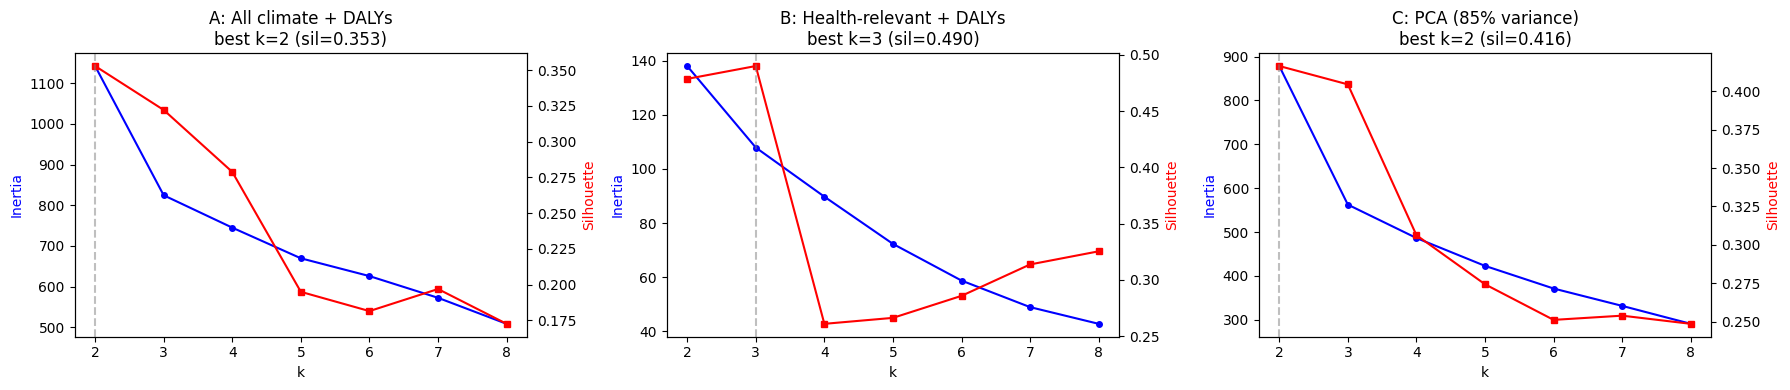


→ Best variant: B: Health-relevant + DALYs
→ Best k: 3
→ Best silhouette: 0.490

Using: B: Health-relevant + DALYs, k=3

CLUSTERING RESULTS (k=3)
  Silhouette score: 0.490
  ARI K-means vs Hierarchical: 1.000
cluster_kmeans
0    28
1    10
2     2
Name: count, dtype: int64


In [97]:
weather_df.columns = weather_df.columns.str.strip()
health_df.columns    = health_df.columns.str.strip()

selected_causes = [
    'Cardiovascular diseases',
    'Chronic respiratory diseases',
    'Environmental heat and cold exposure'
]

health_pivot = (
    health_df[health_df['cause'].isin(selected_causes)]
    [['country', 'year', 'cause', 'DALYs']]
    .pivot_table(index=['country','year'], columns='cause', values='DALYs')
    .reset_index()
)

df = pd.merge(weather_df, health_pivot, on=['country','year'])
df = df.replace([np.inf, -np.inf], np.nan)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

if 'income_level_mode' in health_df.columns:
    income_map = (health_df[['country','income_level_mode']]
                 .drop_duplicates()
                 .groupby('country')['income_level_mode']
                 .first()
                 .to_dict())
else:
    income_map = None

climate_features = [
    c for c in weather_df.columns
    if c not in ['country','year']
    and not c.startswith('Unnamed')
    and 'uncertainty' not in c.lower()
]

for c in selected_causes:
    df[f'log_{c}'] = np.log(df[c].clip(lower=0.01))

log_targets = [f'log_{c}' for c in selected_causes]

country_profile = (
    df.groupby('country')[climate_features + log_targets]
    .mean()
    .reset_index()
    .set_index('country')
    .dropna()
)

if income_map is not None:
    country_profile['income_level'] = country_profile.index.map(income_map)

print(f"Countries: {len(country_profile)}")
print(f"Climate features: {len(climate_features)}")
print("Index unique:", country_profile.index.is_unique)
health_relevant = [
    'caurion_area', 'anomaly_dry_area', 'annual_freeze_burden',
    'extreme_heat_episodes', 'mean_annual_net',
    'mean_annual_rsn',
    'pm2.5_mean',
    'winter_mean_snow_density'
]
health_relevant = [v for v in health_relevant if v in country_profile.columns]

sc = StandardScaler()

# A: всі змінні
X_all = sc.fit_transform(country_profile[climate_features + log_targets])

# B: health-relevant
sc_b = StandardScaler()
X_health = sc_b.fit_transform(country_profile[health_relevant + log_targets])

# C: PCA
sc_c = StandardScaler()
X_std = sc_c.fit_transform(country_profile[climate_features + log_targets])
pca_full = PCA(n_components=0.85, random_state=42)
X_pca = pca_full.fit_transform(X_std)
n_components = X_pca.shape[1]
print(f"\nPCA: {n_components} components explain 85% variance")

VARIANTS = {
    'A: All climate + DALYs': X_all,
    'B: Health-relevant + DALYs': X_health,
    'C: PCA (85% variance)': X_pca,
}

print("\nOPTIMAL K SELECTION — ALL VARIANTS")
print("-"*60)

ks = range(2, 9)
best_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (vname, Xv) in zip(axes, VARIANTS.items()):
    sils = []
    ines = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        lbl = km.fit_predict(Xv)
        sils.append(silhouette_score(Xv, lbl))
        ines.append(km.inertia_)

    best_k_v = list(ks)[np.argmax(sils)]
    best_results[vname] = {
        'best_k': best_k_v,
        'best_sil': max(sils),
        'X': Xv
    }

    ax2 = ax.twinx()
    ax.plot(list(ks), ines, 'b-o', markersize=4)
    ax2.plot(list(ks), sils, 'r-s', markersize=4)
    ax.set_xlabel('k')
    ax.set_ylabel('Inertia', color='b')
    ax2.set_ylabel('Silhouette', color='r')
    ax.set_title(f'{vname}\nbest k={best_k_v} (sil={max(sils):.3f})')
    ax2.axvline(best_k_v, color='gray', linestyle='--', alpha=0.5)

    print(f"\n  {vname}:")
    for k, s in zip(ks, sils):
        marker = ' ←' if k == best_k_v else ''
        print(f"    k={k}: silhouette={s:.3f}{marker}")

plt.tight_layout()
plt.savefig('clustering_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_variant = max(best_results, key=lambda v: best_results[v]['best_sil'])
best_k = best_results[best_variant]['best_k']
X = best_results[best_variant]['X']

print(f"\n→ Best variant: {best_variant}")
print(f"→ Best k: {best_k}")
print(f"→ Best silhouette: {best_results[best_variant]['best_sil']:.3f}")
K = best_k
print(f"\nUsing: {best_variant}, k={K}")

km = KMeans(n_clusters=K, random_state=42, n_init=50)
country_profile['cluster_kmeans'] = km.fit_predict(X)

hc = AgglomerativeClustering(n_clusters=K, linkage='ward')
country_profile['cluster_hier'] = hc.fit_predict(X)

ari = adjusted_rand_score(country_profile['cluster_kmeans'], country_profile['cluster_hier'])
sil = silhouette_score(X, country_profile['cluster_kmeans'])

print(f"\nCLUSTERING RESULTS (k={K})")
print(f"  Silhouette score: {sil:.3f}")
print(f"  ARI K-means vs Hierarchical: {ari:.3f}")
print(country_profile['cluster_kmeans'].value_counts())

Only two clusters show extreme imbalance (2/10/28 countries). Cluster 2 contains only 2 countries = statistically unstable, and 70% of the countries are in a single cluster. PCA with 7 components = the data is chaotic.

Now I'll try to include annual extremes. Also I change scaler and clustering method.


METRICS FOR OPTIMAL K SELECTION (GMM)
------------------------------------------------------------
k=2: Silhouette=0.396 | BIC=802.5
k=3: Silhouette=0.335 | BIC=-104.5
k=4: Silhouette=0.237 | BIC=-579.7
k=5: Silhouette=0.217 | BIC=-783.8
k=6: Silhouette=0.173 | BIC=-543.5
k=7: Silhouette=0.161 | BIC=-620.2
k=8: Silhouette=0.145 | BIC=-330.6


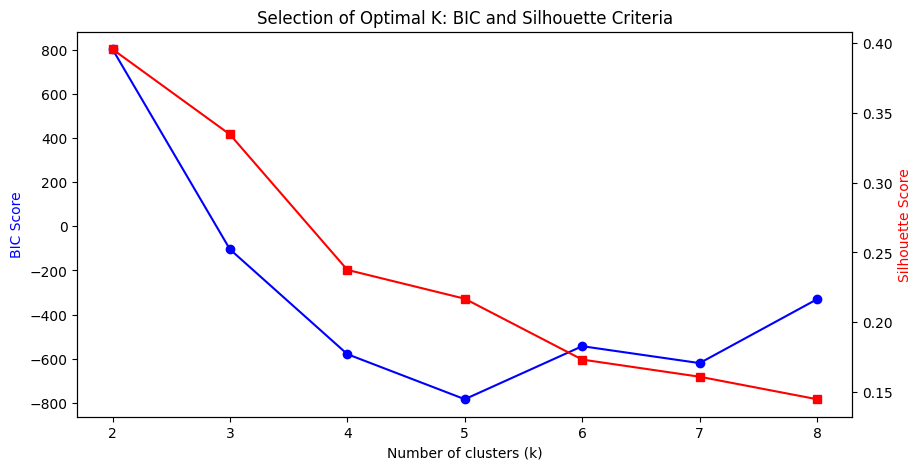


CLUSTERING RESULTS (k=3)
Silhouette score: 0.335

Розподіл по кластерах:
cluster_final
0    18
1    11
2    11
Name: count, dtype: int64

Final Cluster Profiles:
               extreme_freq  seasonal_diff  pm25_mean_mean  \
cluster_final                                                
0                     5.721         34.125          26.613   
1                     2.644         62.877          28.433   
2                     2.893         65.881          16.377   

               log_Cardiovascular diseases_mean  
cluster_final                                    
0                                         8.603  
1                                         8.736  
2                                         8.375  


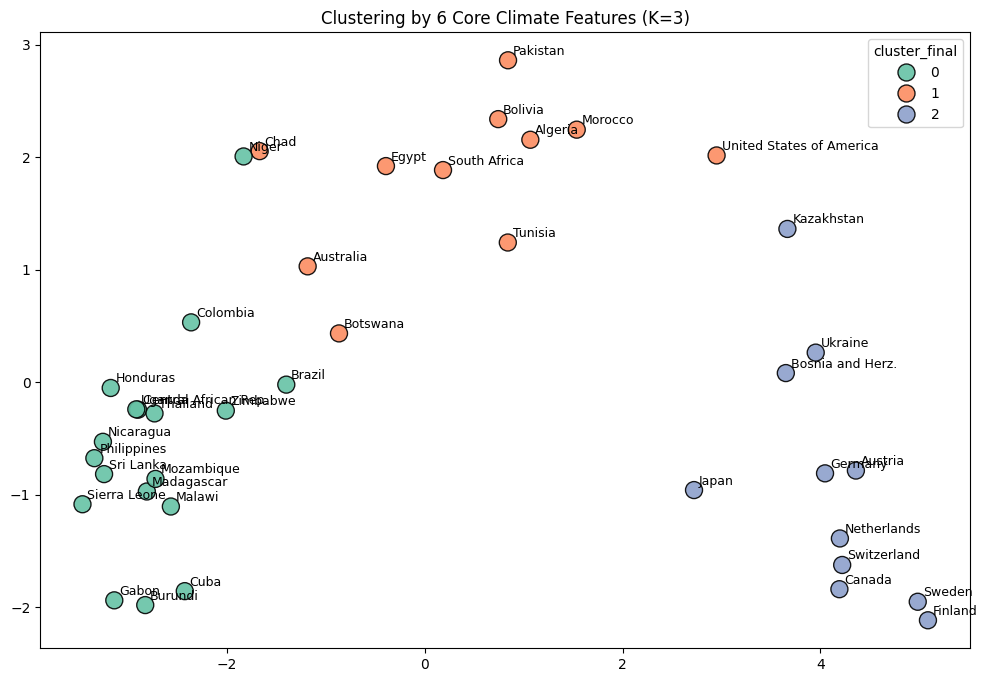

In [102]:
extreme_counts = extreme_df.groupby('country').agg({
    'is_extreme': 'sum',
    'year': 'nunique'
})
extreme_counts['extreme_freq'] = extreme_counts['is_extreme'] / extreme_counts['year']

health_relevant = [
    'annual_freeze_burden', 'extreme_heat_episodes', 'pm25_mean', 
    'winter_mean_snow_density', 'max_temp', 'min_temp', 'max_runoff'
]
health_relevant = [v for v in health_relevant if v in weather_df.columns]

country_profile = df.groupby('country').agg({
    **{c: ['mean', 'std'] for c in health_relevant},
    **{c: 'mean' for c in log_targets}
})

country_profile.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) else col 
    for col in country_profile.columns
]

country_profile = country_profile.join(extreme_counts[['extreme_freq']])
country_profile['seasonal_diff'] = country_profile['max_temp_mean'] - country_profile['min_temp_mean']

country_profile = country_profile.dropna()

current_log_targets = [f"{t}_mean" for t in log_targets]
cluster_features = [c for c in country_profile.columns if any(x in c for x in ['_mean', '_std', 'freq', 'diff'])]
cluster_features = [c for c in cluster_features if 'log_' not in c]

scaler = PowerTransformer()
X_scaled = scaler.fit_transform(country_profile[cluster_features])

ks = range(2, 9)
sils = []
bics = []

print("\nMETRICS FOR OPTIMAL K SELECTION (GMM)")
print("-"*60)

for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    
    sils.append(sil)
    bics.append(bic)
    
    print(f"k={k}: Silhouette={sil:.3f} | BIC={bic:.1f}")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(ks, bics, 'b-o', label='BIC (Lower is better)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('BIC Score', color='b')

ax2 = ax1.twinx()
ax2.plot(ks, sils, 'r-s', label='Silhouette (Higher is better)')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title("Selection of Optimal K: BIC and Silhouette Criteria")
plt.show()
K_FINAL = 3 
gmm_final = GaussianMixture(n_components=K_FINAL, random_state=42, n_init=20)
country_profile['cluster_final'] = gmm_final.fit_predict(X_scaled)
print(f"\nCLUSTERING RESULTS (k={K_FINAL})")
print(f"Silhouette score: {silhouette_score(X_scaled, country_profile['cluster_final']):.3f}")
print("\nРозподіл по кластерах:")
print(country_profile['cluster_final'].value_counts())
final_comparison = country_profile.groupby('cluster_final').agg({
    'extreme_freq': 'mean',
    'seasonal_diff': 'mean',
    'pm25_mean_mean': 'mean',
    'log_Cardiovascular diseases_mean': 'mean'
}).round(3)

print("\nFinal Cluster Profiles:")
print(final_comparison)


pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=country_profile['cluster_final'], 
                palette='Set2', s=150, edgecolor='black', alpha=0.9)

for i, country in enumerate(country_profile.index):
    plt.text(coords[i, 0]+0.05, coords[i, 1]+0.05, country, fontsize=9)

plt.title(f"Clustering by 6 Core Climate Features (K={K_FINAL})")
plt.show()

Distribution of clusters is much better even though Silhouette score dropped significantly. Also I decided to use 3 clusters instead of 2 because BIC improved significantly with 3 clusters.

Now that I'll use fewer variables.

METRICS FOR CORE CLIMATE FEATURES
k=2: Silhouette=0.450 | BIC=435.4
k=3: Silhouette=0.419 | BIC=290.6
k=4: Silhouette=0.433 | BIC=259.2
k=5: Silhouette=0.335 | BIC=193.7
k=6: Silhouette=0.349 | BIC=143.4

Розподіл по кластерах:
cluster_final
2    15
1    13
0    12
Name: count, dtype: int64

Final Profiles (Climate Clusters vs Health Burden):
               extreme_freq  seasonal_diff  pm25_mean_mean  \
cluster_final                                                
0                     2.870         68.423          15.970   
1                     2.805         56.461          31.361   
2                     6.198         31.701          24.840   

               log_Cardiovascular diseases_mean  \
cluster_final                                     
0                                         8.371   
1                                         8.722   
2                                         8.615   

               log_Chronic respiratory diseases_mean  \
cluster_final                   

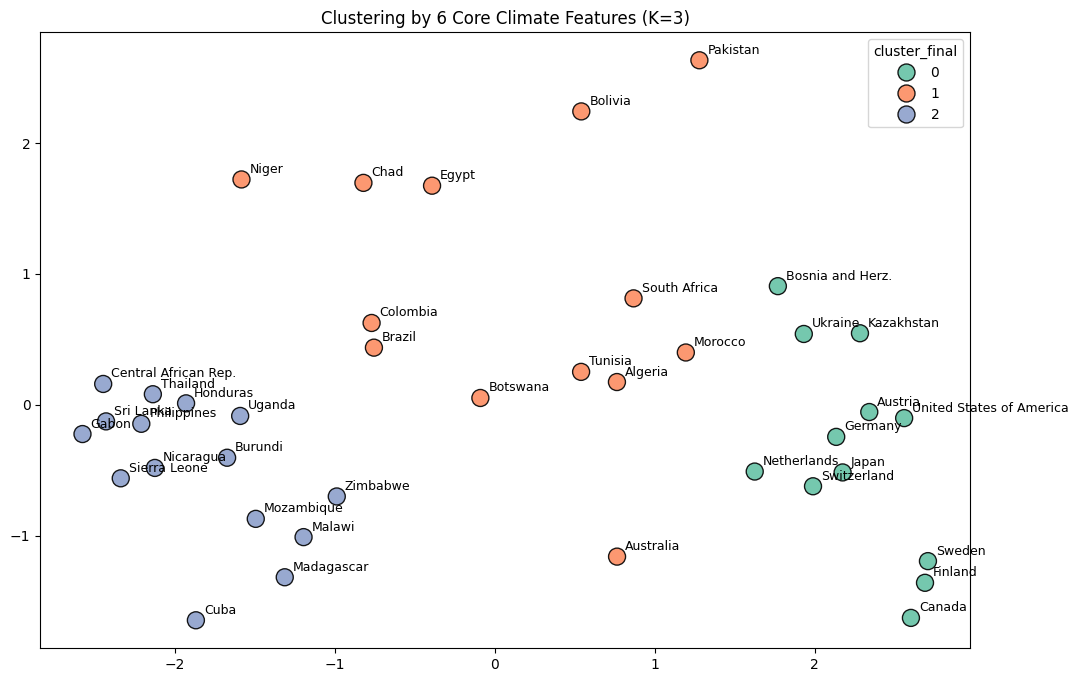

In [36]:
CORE_CLIMATE_FEATURES = [
    'extreme_freq',             
    'seasonal_diff',           
    'annual_freeze_burden_mean',
    'extreme_heat_episodes_mean',
    'pm25_mean_mean', 
    'mean_annual_net_solar_mean'
]

CORE_CLIMATE_FEATURES = [c for c in CORE_CLIMATE_FEATURES if c in country_profile.columns]
X_shrunk = country_profile[CORE_CLIMATE_FEATURES]

scaler = PowerTransformer()
X_shrunk_scaled = scaler.fit_transform(X_shrunk)
ks = range(2, 7)
print("\nMETRICS FOR CORE CLIMATE FEATURES")
print("="*60)

for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_shrunk_scaled)
    sil = silhouette_score(X_shrunk_scaled, labels)
    bic = gmm.bic(X_shrunk_scaled)
    print(f"k={k}: Silhouette={sil:.3f} | BIC={bic:.1f}")

K_FINAL = 3
gmm_final = GaussianMixture(n_components=K_FINAL, random_state=42, n_init=20)
country_profile['cluster_final'] = gmm_final.fit_predict(X_shrunk_scaled)

print("\nDistribution by cluster:")
print(country_profile['cluster_final'].value_counts())

final_analysis = country_profile.groupby('cluster_final').agg({
    'extreme_freq': 'mean',
    'seasonal_diff': 'mean',
    'pm25_mean_mean': 'mean',
    'log_Cardiovascular diseases_mean': 'mean',
    'log_Chronic respiratory diseases_mean': 'mean',
    'log_Environmental heat and cold exposure_mean': 'mean'
}).round(3)

print("\nFinal Profiles (Climate Clusters vs Health Burden):")
print(final_analysis)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_shrunk_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=country_profile['cluster_final'], 
                palette='Set2', s=150, edgecolor='black', alpha=0.9)

for i, country in enumerate(country_profile.index):
    plt.text(coords[i, 0]+0.05, coords[i, 1]+0.05, country, fontsize=9)

plt.title(f"Clustering by 6 Core Climate Features (K={K_FINAL})")
plt.show()

Distribution of clusters is even better and Silhouette score also improved.

Let's check stability

In [99]:
ks = range(2, 7)
print("\nMETRICS FOR CORE CLIMATE FEATURES")
print("="*80)

metrics_df = []
for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_shrunk_scaled)
    
    sil = silhouette_score(X_shrunk_scaled, labels)
    ch_score = calinski_harabasz_score(X_shrunk_scaled, labels)
    bic = gmm.bic(X_shrunk_scaled)
    sil_stability = np.std([
        silhouette_score(X_shrunk_scaled, 
                        GaussianMixture(n_components=k, random_state=i, n_init=5)
                        .fit_predict(X_shrunk_scaled))
        for i in range(10)
    ])
    
    metrics_df.append({
        'k': k, 'Silhouette': sil, 'Silhouette_std': sil_stability,
        'Calinski-Harabasz': ch_score, 'BIC': bic
    })
    
    print(f"k={k:2d}: Silhouette={sil:.3f}(±{sil_stability:.3f}) | "
          f"CH={ch_score:6.0f} | BIC={bic:7.1f}")


METRICS FOR CORE CLIMATE FEATURES
k= 2: Silhouette=0.450(±0.000) | CH=    44 | BIC=  435.4
k= 3: Silhouette=0.419(±0.004) | CH=    40 | BIC=  290.6
k= 4: Silhouette=0.433(±0.028) | CH=    37 | BIC=  259.2
k= 5: Silhouette=0.335(±0.052) | CH=    30 | BIC=  193.7
k= 6: Silhouette=0.349(±0.038) | CH=    28 | BIC=  143.4


The optimal number of clusters, K=3, was chosen as a compromise between 
mathematical quality and interpretability. Although K=2 yields the highest 
Silhouette score (0.450), K=3 provides a significant improvement in BIC 
(435.4→290.6) with minimal loss in Silhouette (0.419, Δ=0.031) and 
excellent stability (±0.004). The three-cluster typology (Cold/ 
Temperate/Warm climate) has a clear physical interpretation for 
climate-health analysis.

**Validation of the climate-health clustering.**
After GMM clustering (K=3), we: 
1) show the composition of the clusters (which countries),
2) visualize the distribution of DALYs 
(boxplot+stripplot),
3) perform an ANOVA to test whether the incidence rates differ **statistically 
significantly** across climate types. 

**Objective**: to demonstrate that climate clusters are relevant to health.

COMPOSITION OF CLIMATE-HEALTH CLUSTERS
------------------------------------------------------------

КЛАСТЕР 0 (12 країн):
Austria, Bosnia and Herz., Canada, Finland, Germany, Japan, Kazakhstan, Netherlands, Sweden, Switzerland, Ukraine, United States of America

КЛАСТЕР 1 (13 країн):
Algeria, Australia, Bolivia, Botswana, Brazil, Chad, Colombia, Egypt, Morocco, Niger, Pakistan, South Africa, Tunisia

КЛАСТЕР 2 (15 країн):
Burundi, Central African Rep., Cuba, Gabon, Honduras, Madagascar, Malawi, Mozambique, Nicaragua, Philippines, Sierra Leone, Sri Lanka, Thailand, Uganda, Zimbabwe


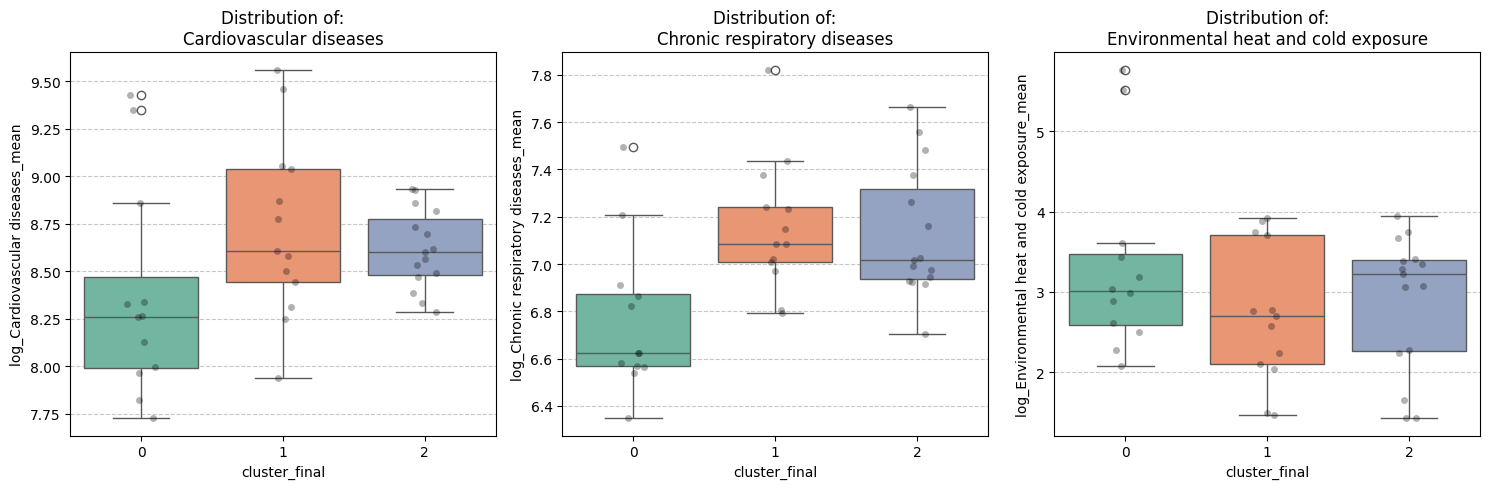

STATISTICAL VALIDATION (ANOVA p-values)
------------------------------------------------------------
log_Cardiovascular diseases                   | p-value: 0.1213
log_Chronic respiratory diseases              | p-value: 0.0025
log_Environmental heat and cold exposure      | p-value: 0.2830


In [88]:
print("COMPOSITION OF CLIMATE-HEALTH CLUSTERS")
print("-"*60)

for c in sorted(country_profile['cluster_final'].unique()):
    countries = country_profile[country_profile['cluster_final'] == c].index.tolist()
    print(f"\nКЛАСТЕР {c} ({len(countries)} країн):")
    print(", ".join(countries))

plt.figure(figsize=(15, 5))

for i, target in enumerate(current_log_targets):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='cluster_final', y=target, data=country_profile, palette='Set2')
    sns.stripplot(x='cluster_final', y=target, data=country_profile, color='black', alpha=0.3)
    clean_title = target.replace('log_', '').replace('_mean', '')
    plt.title(f"Distribution of:\n{clean_title}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("STATISTICAL VALIDATION (ANOVA p-values)")
print("-"*60)

for target in current_log_targets:
    groups = [country_profile[country_profile['cluster_final'] == c][target] 
              for c in country_profile['cluster_final'].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{target.replace('_mean', ''):<45} | p-value: {p_val:.4f}")

**Clustering was confirmed for respiratory diseases (p=0.0025).** 

CLUSTER 0 (Developed, cold): Austria, Canada, Germany... — **low** 
   DALYs (wealthy countries + good healthcare)

CLUSTER 1 (Subtropical, middle-income): Australia, Brazil, South Africa... — 
   **moderate** DALYs

CLUSTER 2 (Tropical, low-income): Burundi, Honduras, Uganda... — **high** DALYs

Cardio (p=0.12) and Heat/Cold (p=0.28) are not significant — require more data/
controls. **Conclusion**: climate + SES gradient explains the respiratory 
burden (PM2.5+heat). Recommendation: target interventions for Cluster 2.

In [117]:
country_profile1 = country_profile.merge(health_df[['income_level_mode', 'country']], on='country')
country_profile1[['country','cluster_final','income_level_mode']].to_csv('../DATA/clusters.csv', index=False)
country_profile1

,country,annual_freeze_burden_mean,annual_freeze_burden_std,extreme_heat_episodes_mean,extreme_heat_episodes_std,pm25_mean_mean,pm25_mean_std,winter_mean_snow_density_mean,winter_mean_snow_density_std,max_temp_mean,...,max_runoff_mean,max_runoff_std,log_Cardiovascular diseases_mean,log_Chronic respiratory diseases_mean,log_Environmental heat and cold exposure_mean,extreme_freq,seasonal_diff,cluster_final,health_cluster,income_level_mode
0,Algeria,5.229623,2.483009,223.852941,10.156748,15.344118,1.586151,103.797879,1.860137,49.033428,...,0.019772,0.007439,9.050981,6.806523,2.048579,2.617647,57.988503,1,1,LM
1,Algeria,5.229623,2.483009,223.852941,10.156748,15.344118,1.586151,103.797879,1.860137,49.033428,...,0.019772,0.007439,9.050981,6.806523,2.048579,2.617647,57.988503,1,1,LM
2,Algeria,5.229623,2.483009,223.852941,10.156748,15.344118,1.586151,103.797879,1.860137,49.033428,...,0.019772,0.007439,9.050981,6.806523,2.048579,2.617647,57.988503,1,1,LM
3,Algeria,5.229623,2.483009,223.852941,10.156748,15.344118,1.586151,103.797879,1.860137,49.033428,...,0.019772,0.007439,9.050981,6.806523,2.048579,2.617647,57.988503,1,1,LM
4,Algeria,5.229623,2.483009,223.852941,10.156748,15.344118,1.586151,103.797879,1.860137,49.033428,...,0.019772,0.007439,9.050981,6.806523,2.048579,2.617647,57.988503,1,1,LM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,Zimbabwe,0.000373,0.001685,186.558824,31.592281,16.785294,1.589956,99.999980,0.000000,42.111452,...,0.093216,0.044055,8.600356,7.161808,3.379597,4.441176,39.974200,0,0,L
4076,Zimbabwe,0.000373,0.001685,186.558824,31.592281,16.785294,1.589956,99.999980,0.000000,42.111452,...,0.093216,0.044055,8.600356,7.161808,3.379597,4.441176,39.974200,0,0,L
4077,Zimbabwe,0.000373,0.001685,186.558824,31.592281,16.785294,1.589956,99.999980,0.000000,42.111452,...,0.093216,0.044055,8.600356,7.161808,3.379597,4.441176,39.974200,0,0,L
4078,Zimbabwe,0.000373,0.001685,186.558824,31.592281,16.785294,1.589956,99.999980,0.000000,42.111452,...,0.093216,0.044055,8.600356,7.161808,3.379597,4.441176,39.974200,0,0,L


Do the clusters correspond to income levels?

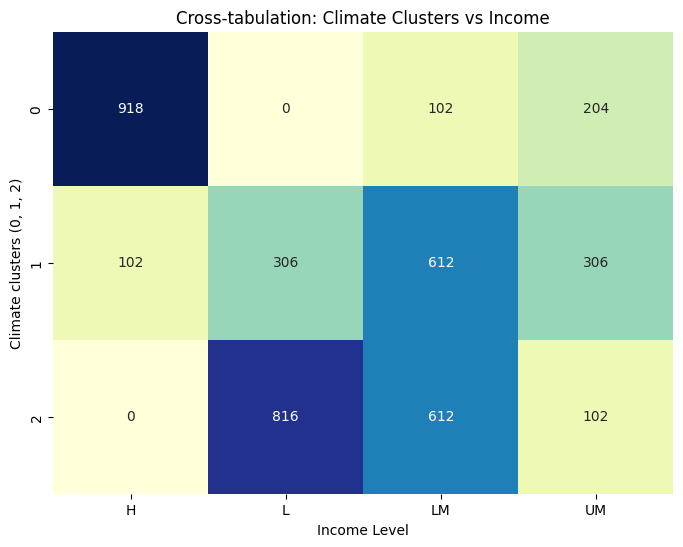

ARI: 0.291


In [90]:
ctab = pd.crosstab(country_profile1['cluster_final'], country_profile1['income_level_mode'])
plt.figure(figsize=(8, 6))
sns.heatmap(ctab, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title("Cross-tabulation: Climate Clusters vs Income")
plt.ylabel("Climate clusters (0, 1, 2)")
plt.xlabel("Income Level")
plt.show()
valid_mask = country_profile1['income_level_mode'].notna()
ari_income = adjusted_rand_score(
    country_profile1.loc[valid_mask, 'cluster_final'], 
    country_profile1.loc[valid_mask, 'income_level_mode']
)
print(f"ARI: {ari_income:.3f}")

Clusters are not the same as income

Now let's see if there're countries with DALYs significantly higher or lower than expected given their climatic and economic profile. Case study: Ukraine

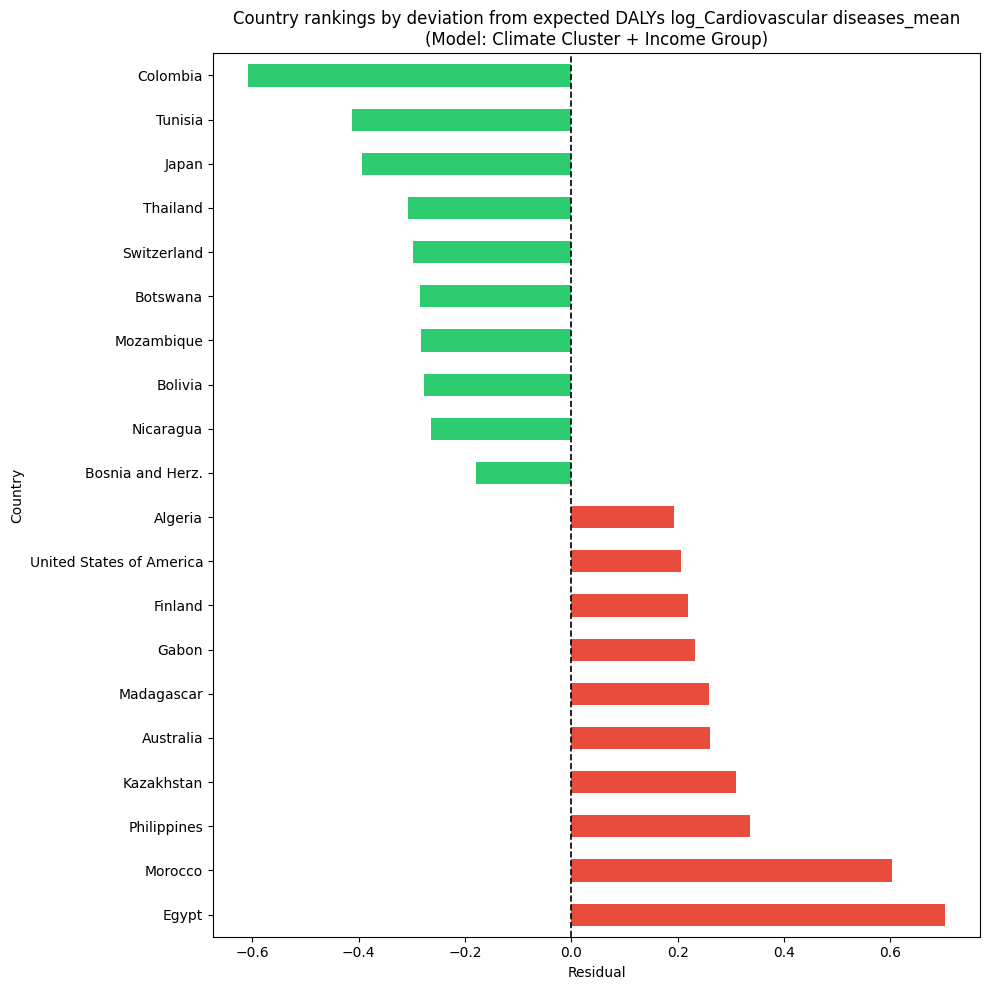


CASE-STUDY: UKRAINE
----------log_Cardiovascular diseases_mean----------------
Actual DALY:   9.4285
Expected according to the model:    9.2988
Residual:    0.1297

The burden of disease in Ukraine is higher than expected
taking into account its climate cluster (0) and income (LM).


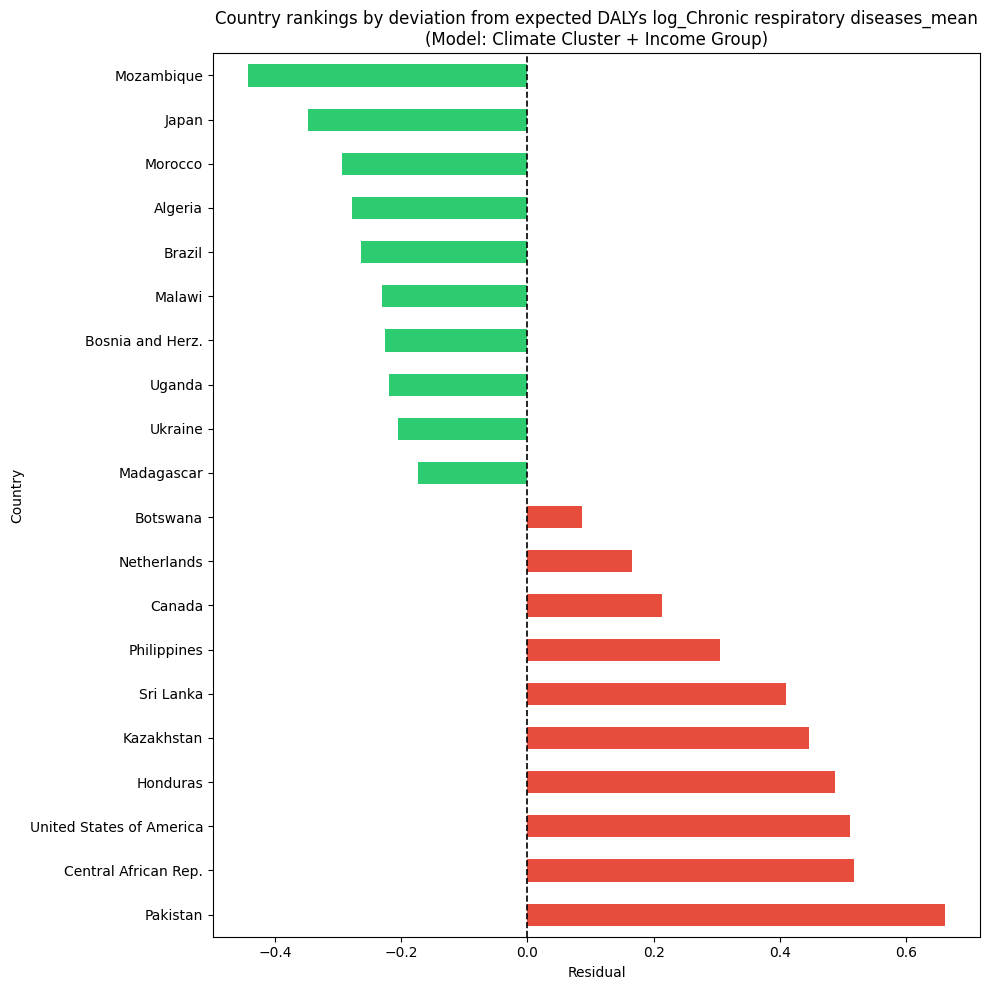


CASE-STUDY: UKRAINE
----------log_Chronic respiratory diseases_mean----------------
Actual DALY:   6.5828
Expected according to the model:    6.7872
Residual:    -0.2044

The burden of disease in Ukraine is lower than expected
taking into account its climate cluster (0) and income (LM).


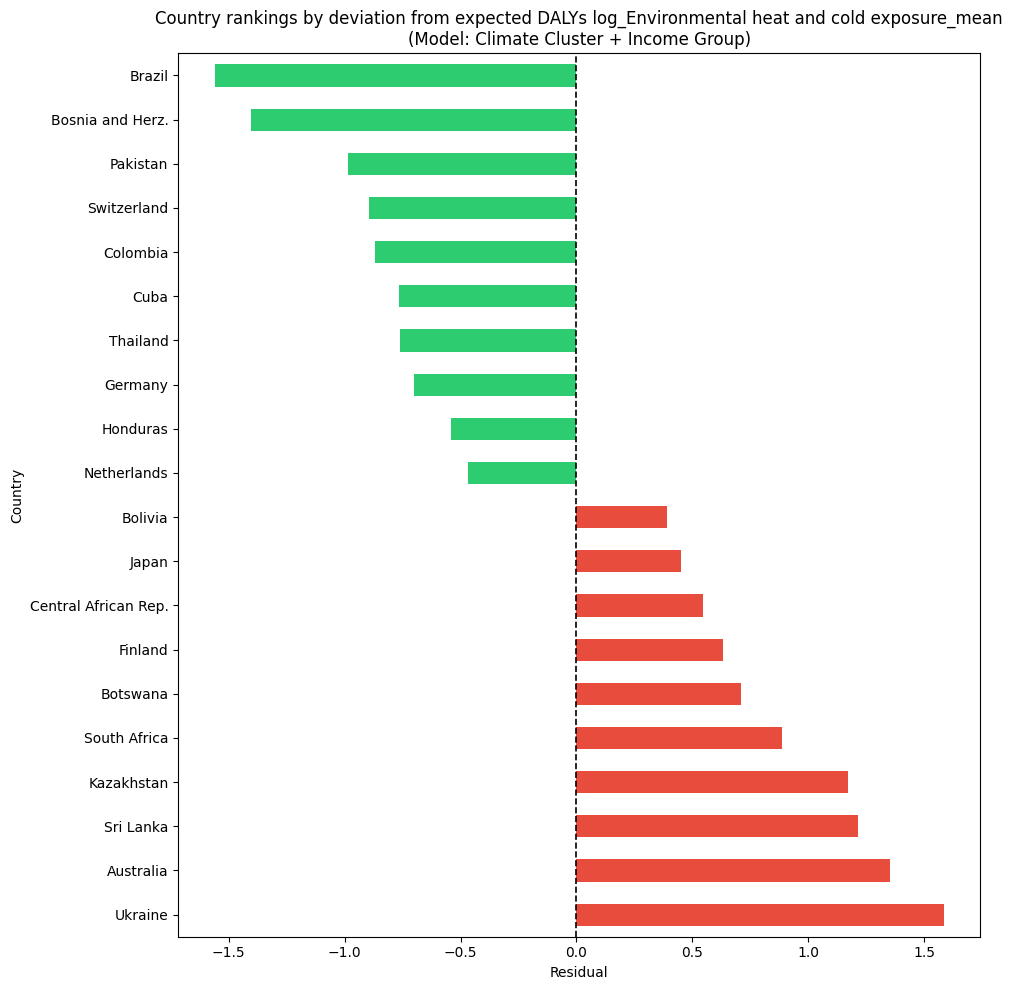


CASE-STUDY: UKRAINE
----------log_Environmental heat and cold exposure_mean----------------
Actual DALY:   5.5100
Expected according to the model:    3.9264
Residual:    1.5837

The burden of disease in Ukraine is higher than expected
taking into account its climate cluster (0) and income (LM).


In [73]:
def run_final_unique_analysis(df, target_col):
    if 'country' in df.columns:
        df_grouped = df.groupby('country').agg({
            target_col: 'mean',
            'cluster_final': 'first',
            'income_level_mode': 'first'
        }).dropna()
    else:
        df_grouped = df.groupby(df.index).agg({
            target_col: 'mean',
            'cluster_final': 'first',
            'income_level_mode': 'first'
        }).dropna()

    df_grouped['target'] = df_grouped[target_col]
    formula = 'target ~ C(cluster_final) + C(income_level_mode)'
    model = ols(formula, data=df_grouped).fit()

    df_grouped['expected'] = model.predict(df_grouped)
    df_grouped['residual'] = df_grouped['target'] - df_grouped['expected']
    
    return df_grouped.sort_values('residual', ascending=False)

targets = ['log_Cardiovascular diseases_mean', 'log_Chronic respiratory diseases_mean', 'log_Environmental heat and cold exposure_mean']
for target in targets:
    final_results = run_final_unique_analysis(country_profile1, target)
    plt.figure(figsize=(10, 10))
    plot_data = pd.concat([final_results.head(10), final_results.tail(10)])
    colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in plot_data['residual']]

    plot_data['residual'].plot(kind='barh', color=colors)
    plt.axvline(0, color='black', lw=1.2, ls='--')
    plt.title(f"Country rankings by deviation from expected DALYs {target}\n(Model: Climate Cluster + Income Group)")
    plt.xlabel("Residual")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

    ukraine_name = [idx for idx in final_results.index if 'Ukraine' in str(idx)]

    if ukraine_name:
        name = ukraine_name[0]
        row = final_results.loc[name]
        print(f"\nCASE-STUDY: {str(name).upper()}")
        print(f"----------{target}----------------")
        print(f"Actual DALY:   {float(row['target']):.4f}")
        print(f"Expected according to the model:    {float(row['expected']):.4f}")
        print(f"Residual:    {float(row['residual']):.4f}")
        
        status = "higher" if row['residual'] > 0 else "lower"
        print(f"\nThe burden of disease in Ukraine is {status} than expected")
        print(f"taking into account its climate cluster ({row['cluster_final']}) and income ({row['income_level_mode']}).")
    else:
        print(f"\nNo Ukraine data.")

Let's see clusters on map.

In [107]:
map_df = country_profile.reset_index()
iso_map = health_df[['country', 'iso3']].drop_duplicates().set_index('country')['iso3'].to_dict()
map_df['iso3'] = map_df['country'].map(iso_map)

cluster_names = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2"
}
map_df['Cluster_Name'] = map_df['cluster_final'].map(cluster_names)
fig = px.choropleth(
    map_df,
    locations="iso3",
    color="Cluster_Name",
    hover_name="country",
    hover_data={
        "extreme_freq": ":.2f", 
        "pm25_mean_mean": ":.1f",
        "seasonal_diff": ":.1f",
        "iso3": False,
        "Cluster_Name": False
    },
    title="Global Health-Centric Climate Clusters",
    color_discrete_map={
        cluster_names[0]: "#2ecc71",
        cluster_names[1]: "#e74c3c",
        cluster_names[2]: "#3498db"
    }
)

fig.update_layout(
    geo=dict(
        showframe=False, 
        showcoastlines=True, 
        projection_type="natural earth",
        showland=True, landcolor="lightgray"
    ),
    margin=dict(l=0, r=0, t=50, b=0),
    legend=dict(
        title="Climate Profiles",
        yanchor="top", y=0.9, xanchor="left", x=0.02
    )
)

fig.show()